Computer Vision Based Disease Classfication

In [3]:
# Install required libraries

!pip install -q kagglehub
!pip install -q scikit-learn
!pip install -q seaborn

# Core Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

# Image Processing & Utilities
import numpy as np
import os

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Evaluation Metrics
from sklearn.metrics import confusion_matrix, classification_report
from collections import Counter

In [4]:
import kagglehub
import os

# Download dataset from Kaggle
dataset_path = kagglehub.dataset_download(
    "tawsifurrahman/covid19-radiography-database"
)

print("Raw Dataset Path:", dataset_path)

# Check folder structure
print("Initial Contents:", os.listdir(dataset_path))

# Fix folder level if nested
if "COVID-19_Radiography_Dataset" in os.listdir(dataset_path):
    dataset_path = os.path.join(dataset_path, "COVID-19_Radiography_Dataset")

print("Final Dataset Path:", dataset_path)
print("Final Contents:", os.listdir(dataset_path))


Using Colab cache for faster access to the 'covid19-radiography-database' dataset.
Raw Dataset Path: /kaggle/input/covid19-radiography-database
Initial Contents: ['COVID-19_Radiography_Dataset']
Final Dataset Path: /kaggle/input/covid19-radiography-database/COVID-19_Radiography_Dataset
Final Contents: ['Lung_Opacity.metadata.xlsx', 'Normal.metadata.xlsx', 'README.md.txt', 'COVID.metadata.xlsx', 'Normal', 'Lung_Opacity', 'Viral Pneumonia.metadata.xlsx', 'Viral Pneumonia', 'COVID']


TensorFlow-Only GPU Check



In [5]:
print("TensorFlow Version:", tf.__version__)

gpus = tf.config.list_physical_devices('GPU')
print("Available GPUs:", gpus)

if gpus:
    print("GPU is available and will be used automatically by TensorFlow.")
else:
    print("No GPU detected. Running on CPU.")

TensorFlow Version: 2.19.0
Available GPUs: []
No GPU detected. Running on CPU.



Dataset Path Verification Block


In [6]:

print("Verifying dataset path...\n")
print("Dataset Path:", dataset_path)

# List all items
items = os.listdir(dataset_path)
print("\nAll items inside dataset folder:")
for item in items:
    print(" -", item)

# Detect only directories (class folders)
class_folders = [
    folder for folder in items
    if os.path.isdir(os.path.join(dataset_path, folder))
]

print("\nDetected class folders:")
for folder in class_folders:
    print(" -", folder)

print("\nNumber of class folders detected:", len(class_folders))


Verifying dataset path...

Dataset Path: /kaggle/input/covid19-radiography-database/COVID-19_Radiography_Dataset

All items inside dataset folder:
 - Lung_Opacity.metadata.xlsx
 - Normal.metadata.xlsx
 - README.md.txt
 - COVID.metadata.xlsx
 - Normal
 - Lung_Opacity
 - Viral Pneumonia.metadata.xlsx
 - Viral Pneumonia
 - COVID

Detected class folders:
 - Normal
 - Lung_Opacity
 - Viral Pneumonia
 - COVID

Number of class folders detected: 4


Image Transform / Preprocessing Block

In [15]:
# Minimal TF prep: split + normalize to [0,1] (no extra imports)

img_size = (224, 224)
batch_size = 32
val_split = 0.2
seed = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=val_split,
    subset="training",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True,
    color_mode='grayscale'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=val_split,
    subset="validation",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True,
    color_mode='grayscale'
)

normalizer = layers.Rescaling(1.0 / 255)
train_ds = train_ds.map(lambda x, y: (normalizer(x), y), num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.map(lambda x, y: (normalizer(x), y), num_parallel_calls=tf.data.AUTOTUNE)

train_ds = train_ds.cache().prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.cache().prefetch(tf.data.AUTOTUNE)

# Keep transform for the downstream torchvision ImageFolder block
transform = None

Found 42330 files belonging to 4 classes.
Using 33864 files for training.
Found 42330 files belonging to 4 classes.
Using 8466 files for validation.


Verify sample images (first 25 from training set)



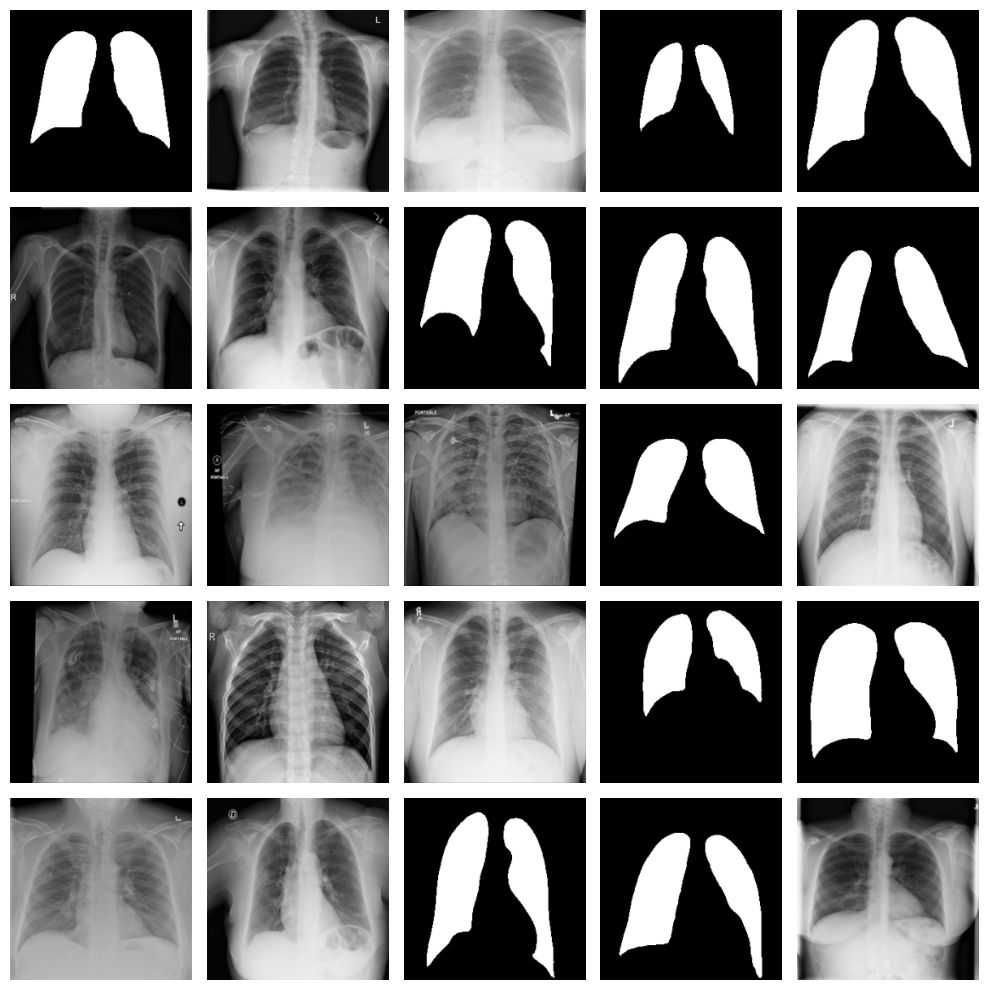

In [9]:
# Get one batch safely
batch_images, batch_labels = next(iter(train_ds))

# If class_names was lost after .map(), define manually
try:
    class_names
except NameError:
    class_names = train_ds.class_names if hasattr(train_ds, "class_names") else None

# Plot first 25 images
plt.figure(figsize=(10, 10))

for i in range(min(25, batch_images.shape[0])):
    ax = plt.subplot(5, 5, i + 1)

    img = batch_images[i].numpy()

    # Handle grayscale properly
    if img.shape[-1] == 1:
        plt.imshow(img.squeeze(), cmap="gray")
    else:
        plt.imshow(img)

    if class_names is not None:
        label_idx = int(batch_labels[i].numpy())
        plt.title(class_names[label_idx], fontsize=8)

    plt.axis("off")

plt.tight_layout()
plt.show()

In [10]:
conv_base = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation="relu", input_shape=(224, 224, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2))
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
conv_base.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 92,672 (362.00 KB)

 Trainable params: 92,672 (362.00 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
conv_base.add(layers.Flatten())
conv_base.add(layers.Dense(128, activation='relu'))
conv_base.add(layers.Dropout(0.5))   # important for medical dataset
conv_base.add(layers.Dense(4, activation='softmax'))

In [13]:
conv_base.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,168,900 (42.61 MB)

 Trainable params: 11,168,900 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
conv_base.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = conv_base.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)